<a href="https://colab.research.google.com/github/malneedisaichandu/Sai/blob/dev/ITC_SharePrice_prediction_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance numpy pandas matplotlib scikit-learn tensorflow


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


In [ ]:
data = yf.download('ITC.NS', start='2015-01-01', end='2025-05-12')
data = data[['Close']]  # Use only closing price
data

/tmp/ipython-input-2485169108.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('ITC.NS', start='2015-01-01', end='2025-05-12')
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,ITC.NS
Date,
2015-01-01,177.351044
2015-01-02,177.906570
2015-01-05,178.606995
2015-01-06,174.018021
2015-01-07,170.781586
...,...
2025-05-05,429.044830
2025-05-06,427.670135


In [ ]:
model = Sequential()
model.add(SimpleRNN(units=50, activation='tanh', return_sequences=False, input_shape=(X.shape[1], 1)))
model.add(Dense(units=1))  # Predict the next closing price

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # RNN input shape


In [ ]:
scaled_data

array([[0.15892568],
       [0.16035034],
       [0.16214659],
       ...,
       [0.78979456],
       [0.78840962],
       [0.77065683]])

In [ ]:
X.shape

(2494, 60, 1)

In [ ]:
X[0]

array([[0.15892568],
       [0.16035034],
       [0.16214659],
       [0.15037807],
       [0.14207816],
       [0.15304152],
       [0.14622818],
       [0.14740498],
       [0.15019231],
       [0.13495518],
       [0.14746692],
       [0.15019231],
       [0.14858186],
       [0.16381888],
       [0.14102525],
       [0.13848581],
       [0.13699913],
       [0.15025418],
       [0.15291763],
       [0.16270406],
       [0.16066003],
       [0.15087359],
       [0.15756304],
       [0.15948318],
       [0.1610936 ],
       [0.16679209],
       [0.15985478],
       [0.16233243],
       [0.16388094],
       [0.16295172],
       [0.17242847],
       [0.18673647],
       [0.19125807],
       [0.18630285],
       [0.19472665],
       [0.18754172],
       [0.19429303],
       [0.19924821],
       [0.19423117],
       [0.1918155 ],
       [0.12931864],
       [0.12721281],
       [0.13055742],
       [0.13303503],
       [0.1232486 ],
       [0.12349646],
       [0.1230628 ],
       [0.133

In [ ]:
X[0].shape

(60, 1)

In [ ]:
model.fit(X, y, epochs=20, batch_size=32)


Epoch 1/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0269
Epoch 2/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.8996e-04
Epoch 3/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.3062e-04
Epoch 4/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.7184e-04
Epoch 5/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.4533e-04
Epoch 6/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.8714e-04
Epoch 7/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2269e-04
Epoch 8/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7597e-04
Epoch 9/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2712e-04
Epoch 10/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2115e-04
Epoch 11/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2936e-04
Epoch 12/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0969e-04
Epoch 13/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.2530e-04
Epoch 14/20
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1216e-04
Epoch 15/20
78/78 ━

In [ ]:
predicted_prices = model.predict(X)
predicted_prices = scaler.inverse_transform(predicted_prices)
real_prices = scaler.inverse_transform(y.reshape(-1, 1))


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
real_prices

array([[157.40115356],
       [160.58929443],
       [164.71936035],
       ...,
       [423.34973145],
       [422.80969238],
       [415.88723755]])

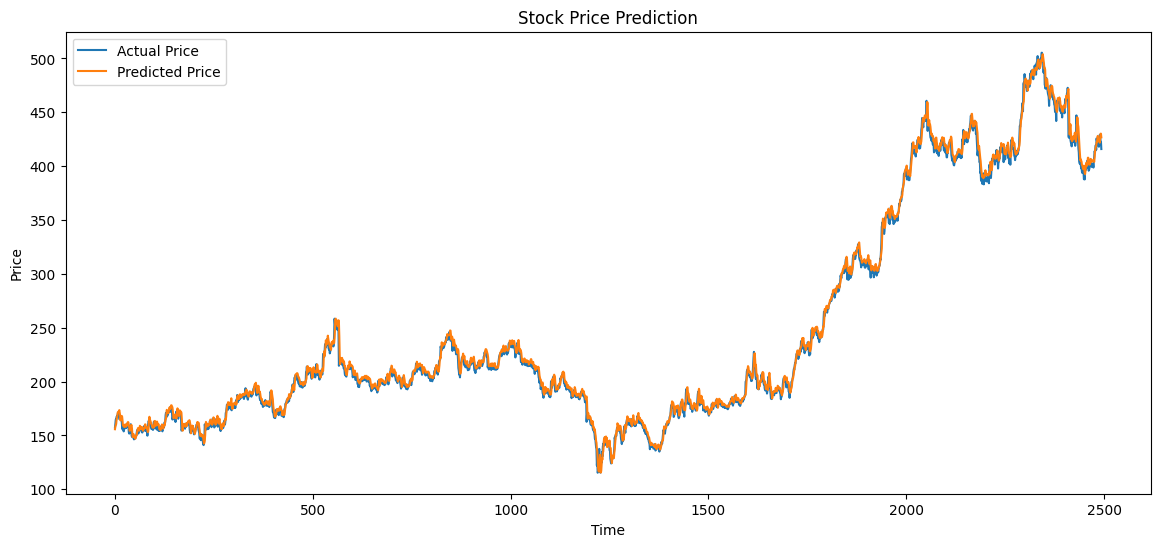

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(real_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


/tmp/ipython-input-724397925.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('ITC.NS', start='2015-01-01')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0073
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6568e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0121e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2534e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8632e-04
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6019e-04
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.3785e-04
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0870e-04
Epoch 9/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8220e-04
Epoch 10/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.3556e-04
Epoch 11/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2.1780e-04
Epoch 12/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.8362e-04
Epoch 13/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.0293e-04
Epoch 14/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1250e-04
Epoch 15/20
82/82 ━

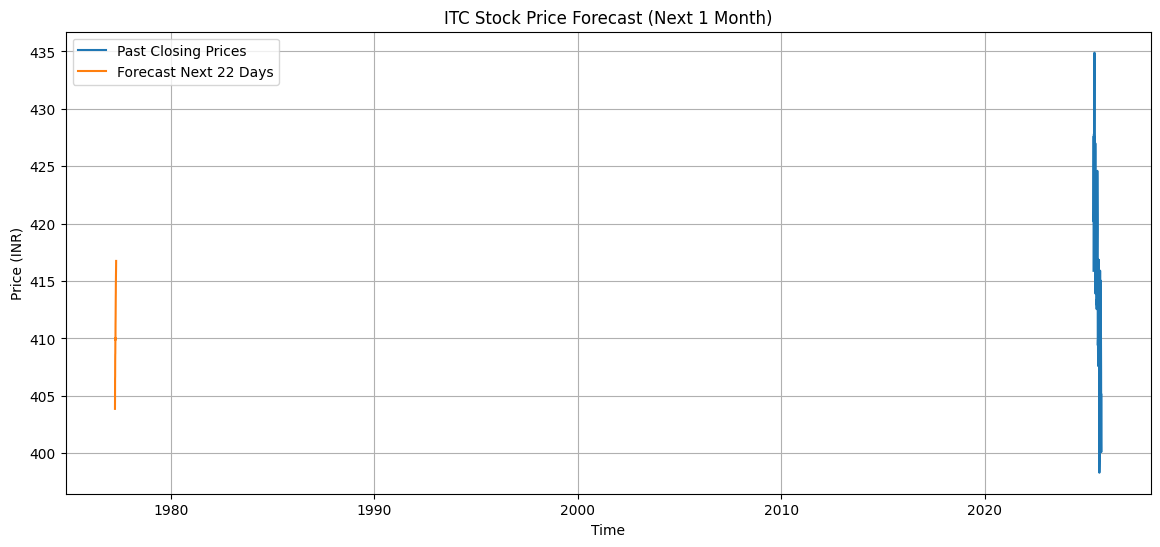

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Step 1: Download ITC Stock Data
df = yf.download('ITC.NS', start='2015-01-01')
data = df[['Close']]

# Step 2: Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Step 3: Create training sequences
sequence_length = 60
X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Step 4: Build the RNN Model
model = Sequential()
model.add(SimpleRNN(units=50, activation='tanh', input_shape=(X.shape[1], 1)))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=20, batch_size=32)

# Step 5: Forecast next 22 days (1 month)
future_days = 22
forecast_input = scaled_data[-sequence_length:]  # last 60 days
forecast = []

for _ in range(future_days):
    x_input = forecast_input.reshape(1, sequence_length, 1)
    next_pred = model.predict(x_input, verbose=0)
    forecast.append(next_pred[0, 0])
    forecast_input = np.append(forecast_input, next_pred)[-sequence_length:]

# Step 6: Invert scaling to get real prices
forecast = np.array(forecast).reshape(-1, 1)
predicted_prices = scaler.inverse_transform(forecast)

# Step 7: Plot the prediction
plt.figure(figsize=(14,6))
plt.plot(data[-100:], label='Past Closing Prices')  # last 100 days
plt.plot(range(len(data), len(data) + future_days), predicted_prices, label='Forecast Next 22 Days')
plt.title('ITC Stock Price Forecast (Next 1 Month)')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()


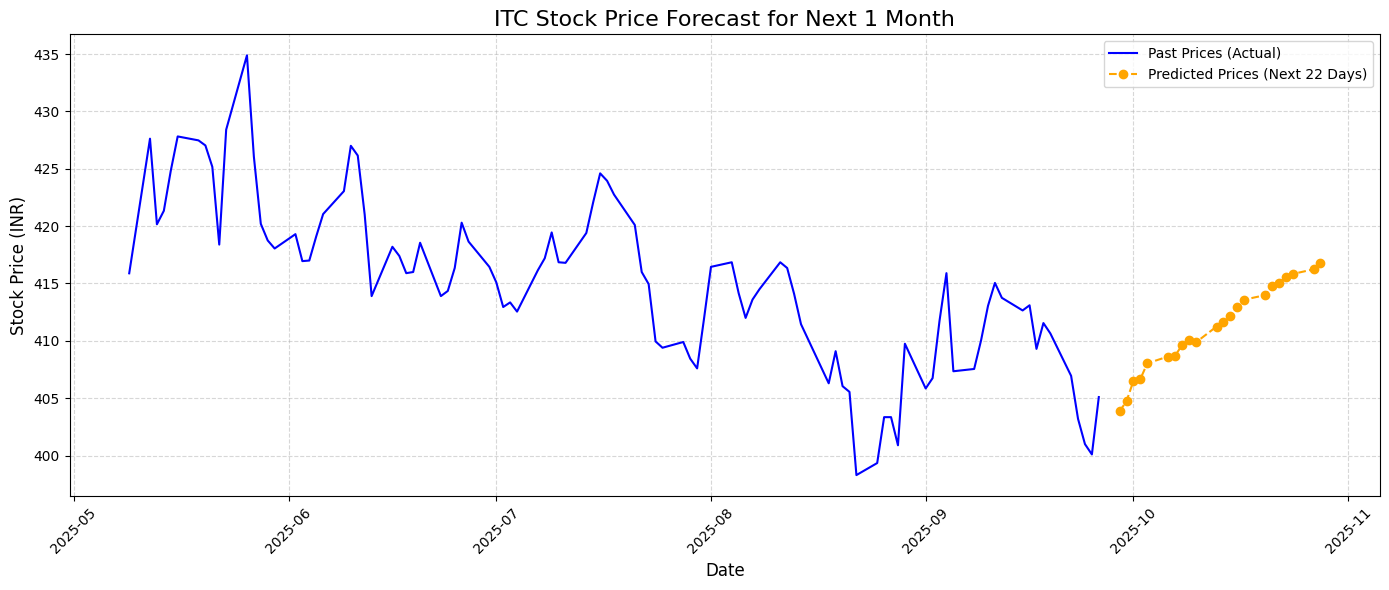

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare X axis
past_days = data[-100:].index
future_days = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=22, freq='B')  # 'B' = business days

# Prepare Y axis
past_prices = data['Close'][-100:].values
future_prices = predicted_prices.flatten()

# Plot
plt.figure(figsize=(14,6))
plt.plot(past_days, past_prices, label='Past Prices (Actual)', color='blue')
plt.plot(future_days, future_prices, label='Predicted Prices (Next 22 Days)', color='orange', linestyle='--', marker='o')

# Enhance Plot
plt.title('ITC Stock Price Forecast for Next 1 Month', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
